## Data preprocessing


In [8]:
from pathlib import Path
from typing import TypeAlias
import json
import pandas as pd

SensorRecord: TypeAlias = dict[str, int | str]
SensorPayload: TypeAlias = dict[str, list[SensorRecord]]
EXPECTED_SENSOR_COLUMNS: list[str] = [
    "aqi-1",
    "aqi-2",
    "aqi-3",
    "aqi-4",
    "aqi-5",
    "co2-1",
    "co2-2",
    "co2-3",
    "co2-4",
    "co2-5",
    "humi-1",
    "humi-2",
    "humi-3",
    "humi-4",
    "humi-5",
    "temp-1",
    "temp-2",
    "temp-3",
    "temp-4",
    "temp-5",
    "tvoc-1",
    "tvoc-2",
    "tvoc-3",
    "tvoc-4",
    "tvoc-5",
]
PI2_DROP_COLUMNS: list[str] = ["aqi-5", "co2-5", "humi-5", "temp-5", "tvoc-5"]

# Workspace root containing JSON inputs.
BASE_DIR: Path = Path.cwd()
INPUT_FILES: list[Path] = [BASE_DIR / "pi-1-data.json", BASE_DIR / "pi-2-data.json"]


def json_to_wide_dataframe(json_path: Path) -> pd.DataFrame:
    """Convert one sensor JSON file into a wide DataFrame keyed by timestamp."""
    with json_path.open("r", encoding="utf-8") as f:
        payload: SensorPayload = json.load(f)

    long_frames: list[pd.DataFrame] = []

    for sensor_name, records in payload.items():
        if not isinstance(records, list):
            continue

        sensor_df = pd.DataFrame(records)
        if (
            sensor_df.empty
            or "ts" not in sensor_df.columns
            or "value" not in sensor_df.columns
        ):
            continue

        sensor_df = sensor_df[["ts", "value"]].rename(
            columns={"ts": "timestamp", "value": "value"}
        )
        sensor_df["value"] = pd.to_numeric(
            sensor_df["value"].replace("N/A", pd.NA), errors="coerce"
        )
        sensor_df["sensor"] = sensor_name
        long_frames.append(sensor_df)

    if not long_frames:
        return pd.DataFrame(columns=["timestamp", *EXPECTED_SENSOR_COLUMNS])

    long_df = pd.concat(long_frames, ignore_index=True)
    wide_df = long_df.pivot_table(
        index="timestamp", columns="sensor", values="value", aggfunc="last"
    )
    wide_df = wide_df.reset_index()
    wide_df.columns.name = None
    wide_df["timestamp"] = pd.to_numeric(wide_df["timestamp"], errors="coerce").astype(
        "Int64"
    )
    wide_df = wide_df.reindex(columns=["timestamp", *EXPECTED_SENSOR_COLUMNS])
    wide_df = wide_df.sort_values("timestamp", na_position="last").reset_index(
        drop=True
    )
    return wide_df


summaries: list[dict[str, int | str]] = []
for input_path in INPUT_FILES:
    if not input_path.exists():
        print(f"Skipping missing file: {input_path.name}")
        continue

    df = json_to_wide_dataframe(input_path)

    # Sensor-5 on pi-2 is known failed during this time window.
    if input_path.name.startswith("pi-2"):
        df = df.drop(columns=PI2_DROP_COLUMNS, errors="ignore")

    output_path = input_path.with_suffix(".csv")
    df.to_csv(output_path, index=False)

    summaries.append(
        {
            "input": input_path.name,
            "output": output_path.name,
            "rows": int(df.shape[0]),
            "columns": int(df.shape[1]),
        }
    )

summary_df = pd.DataFrame(summaries)
summary_df

,input,output,rows,columns
0,pi-1-data.json,pi-1-data.csv,4861,26
1,pi-2-data.json,pi-2-data.csv,4838,21


In [9]:
from typing import Final

RESAMPLE_RULE: Final[str] = "5min"
SHORT_GAP_MAX: Final[int] = 2  # <=10 minutes
MEDIUM_GAP_MAX: Final[int] = 12  # <=60 minutes

# Minimum absolute jump to treat as possible glitch per sensor family.
DELTA_MIN_JUMP: Final[dict[str, float]] = {
    "co2": 180.0,
    "humi": 8.0,
    "temp": 3.0,
    "tvoc": 350.0,
}

FAMILY_SENSOR_COLUMNS: dict[str, list[str]] = {
    "tvoc": ["tvoc-1", "tvoc-2", "tvoc-3", "tvoc-4", "tvoc-5"],
    "co2": ["co2-1", "co2-2", "co2-3", "co2-4", "co2-5"],
    "humidity": ["humi-1", "humi-2", "humi-3", "humi-4", "humi-5"],
    "temp": ["temp-1", "temp-2", "temp-3", "temp-4", "temp-5"],
}


def _sensor_family(column_name: str) -> str:
    if "-" in column_name:
        return column_name.split("-", 1)[0]
    return column_name


def _mark_delta_glitches(
    df_in: pd.DataFrame, value_cols: list[str], z_threshold: float = 6.0
) -> tuple[pd.DataFrame, dict[str, int]]:
    """Mark sample as glitch when jump from previous sample is abnormally high."""
    df_out = df_in.copy()
    glitch_counts: dict[str, int] = {}

    for col in value_cols:
        family = _sensor_family(col)
        s = pd.to_numeric(df_out[col], errors="coerce")
        abs_delta = s.diff().abs()

        delta_median = abs_delta.median(skipna=True)
        delta_mad = (abs_delta - delta_median).abs().median(skipna=True)

        min_jump = DELTA_MIN_JUMP.get(family, 0.0)
        if pd.isna(delta_median):
            glitch_counts[col] = 0
            continue

        if pd.isna(delta_mad) or delta_mad == 0:
            robust_limit = float(delta_median) * 3.0
        else:
            robust_limit = float(delta_median) + z_threshold * 1.4826 * float(delta_mad)

        jump_limit = max(min_jump, robust_limit)
        glitch_mask = abs_delta > jump_limit

        glitch_counts[col] = int(glitch_mask.sum())
        df_out.loc[glitch_mask, col] = pd.NA

    return df_out, glitch_counts


def _apply_selective_gap_fill(
    series_in: pd.Series,
) -> tuple[pd.Series, pd.Series]:
    """Short gaps: ffill, medium gaps: linear interpolate, long gaps: keep missing for drop."""
    s = series_in.copy()
    missing_mask = s.isna()
    group_id = missing_mask.ne(missing_mask.shift(fill_value=False)).cumsum()
    missing_run_length = missing_mask.groupby(group_id).transform("sum")

    short_gap_mask = missing_mask & (missing_run_length <= SHORT_GAP_MAX)
    medium_gap_mask = (
        missing_mask
        & (missing_run_length > SHORT_GAP_MAX)
        & (missing_run_length <= MEDIUM_GAP_MAX)
    )
    long_gap_mask = missing_mask & (missing_run_length > MEDIUM_GAP_MAX)

    s_ffill = s.ffill(limit=SHORT_GAP_MAX)
    s_interp = s.interpolate(
        method="linear", limit=MEDIUM_GAP_MAX, limit_direction="both"
    )

    s_out = s.copy()
    s_out.loc[short_gap_mask] = s_ffill.loc[short_gap_mask]
    s_out.loc[medium_gap_mask] = s_interp.loc[medium_gap_mask]
    return s_out, long_gap_mask


def clean_align_5min(df_raw: pd.DataFrame) -> tuple[pd.DataFrame, dict[str, int]]:
    df = df_raw.copy()

    # Parse and index time.
    df["timestamp"] = pd.to_numeric(df["timestamp"], errors="coerce").astype("Int64")
    df = df.dropna(subset=["timestamp"]).copy()
    df["time"] = pd.to_datetime(df["timestamp"], unit="ms", utc=True)
    df = df.drop(columns=["timestamp"]).set_index("time").sort_index()

    # Keep last if duplicate timestamps present.
    before_dupes = len(df)
    df = df[~df.index.duplicated(keep="last")]
    removed_dupes = before_dupes - len(df)

    sensor_cols = [
        c for cols in FAMILY_SENSOR_COLUMNS.values() for c in cols if c in df.columns
    ]

    # Glitch cleanup from abnormal sample-to-sample jumps.
    df, delta_counts = _mark_delta_glitches(df, sensor_cols)

    # Resample to 5-minute buckets at sensor-channel level first (robust median).
    sensor_5m = df[sensor_cols].resample(RESAMPLE_RULE).median(numeric_only=True)

    # Robust aggregation per variable using median across available sensor locations.
    final_df = pd.DataFrame(index=sensor_5m.index)
    for out_col, source_cols in FAMILY_SENSOR_COLUMNS.items():
        active_cols = [c for c in source_cols if c in sensor_5m.columns]
        if active_cols:
            final_df[out_col] = sensor_5m[active_cols].median(axis=1, skipna=True)
        else:
            final_df[out_col] = pd.NA

    # Count working locations from whatever sensors actually exist in this dataset.
    available_locations = sorted(
        {
            int(c.split("-", 1)[1])
            for c in sensor_cols
            if "-" in c and c.split("-", 1)[1].isdigit()
        }
    )

    working_location_flags: list[pd.Series] = []
    for loc in available_locations:
        loc_cols = [f"tvoc-{loc}", f"co2-{loc}", f"humi-{loc}", f"temp-{loc}"]
        active_loc_cols = [c for c in loc_cols if c in sensor_5m.columns]
        if active_loc_cols:
            working_location_flags.append(
                sensor_5m[active_loc_cols].notna().any(axis=1)
            )

    if working_location_flags:
        valid_sensor_count = (
            pd.concat(working_location_flags, axis=1).sum(axis=1).astype(int)
        )
    else:
        valid_sensor_count = pd.Series(0, index=final_df.index, dtype=int)
    final_df["valid_sensor_count"] = valid_sensor_count

    # Selective missing-data handling by variable.
    long_gap_any = pd.Series(False, index=final_df.index)
    for col in ["tvoc", "co2", "humidity", "temp"]:
        final_df[col], long_gap_mask = _apply_selective_gap_fill(
            pd.to_numeric(final_df[col], errors="coerce")
        )
        long_gap_any = long_gap_any | long_gap_mask

    rows_before_long_drop = len(final_df)
    final_df = final_df.loc[~long_gap_any].copy()
    rows_dropped_long_gaps = rows_before_long_drop - len(final_df)

    final_df = final_df.reset_index()

    report = {
        "rows_in": int(len(df_raw)),
        "rows_5min": int(len(final_df)),
        "rows_with_le_2_sensors_working": int(
            (final_df["valid_sensor_count"] <= 2).sum()
        ),
        "dupe_timestamps_removed": int(removed_dupes),
        "delta_glitches_marked_total": int(sum(delta_counts.values())),
        "rows_dropped_long_gaps": int(rows_dropped_long_gaps),
        "missing_after_fill_total": int(
            final_df[["tvoc", "co2", "humidity", "temp"]].isna().sum().sum()
        ),
    }
    return final_df, report


cleaned_reports: list[dict[str, int | str]] = []
cleaned_frames: dict[str, pd.DataFrame] = {}

for input_name in ["pi-1-data.csv", "pi-2-data.csv"]:
    input_path = BASE_DIR / input_name
    if not input_path.exists():
        print(f"Skipping missing CSV: {input_name}")
        continue

    raw_df = pd.read_csv(input_path)
    cleaned_df, stats = clean_align_5min(raw_df)
    cleaned_frames[input_name] = cleaned_df

    out_name = input_name.replace(".csv", "-clean-5min.csv")
    out_path = BASE_DIR / out_name
    cleaned_df.to_csv(out_path, index=False)

    cleaned_reports.append(
        {
            "input": input_name,
            "output": out_name,
            **stats,
        }
    )

clean_report_df = pd.DataFrame(cleaned_reports)
clean_report_df

,input,output,rows_in,rows_5min,rows_with_le_2_sensors_working,dupe_timestamps_removed,delta_glitches_marked_total,rows_dropped_long_gaps,missing_after_fill_total
0,pi-1-data.csv,pi-1-data-clean-5min.csv,4861,4873,24,0,236,0,0
1,pi-2-data.csv,pi-2-data-clean-5min.csv,4838,4874,48,0,110,0,0


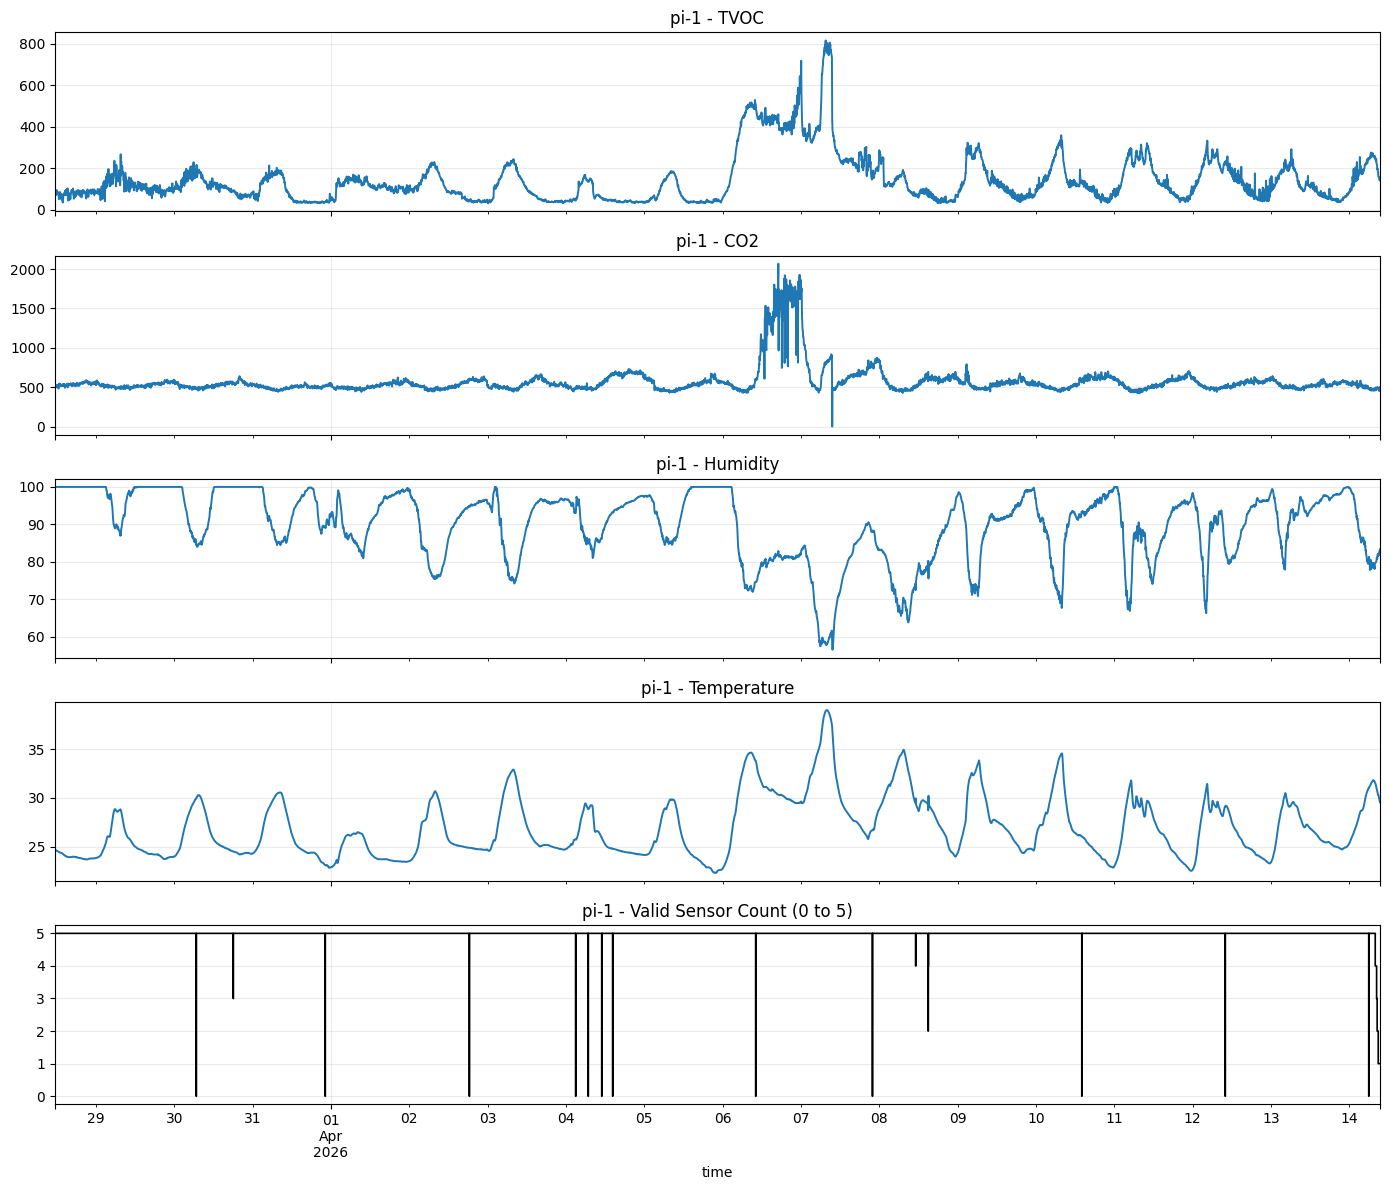

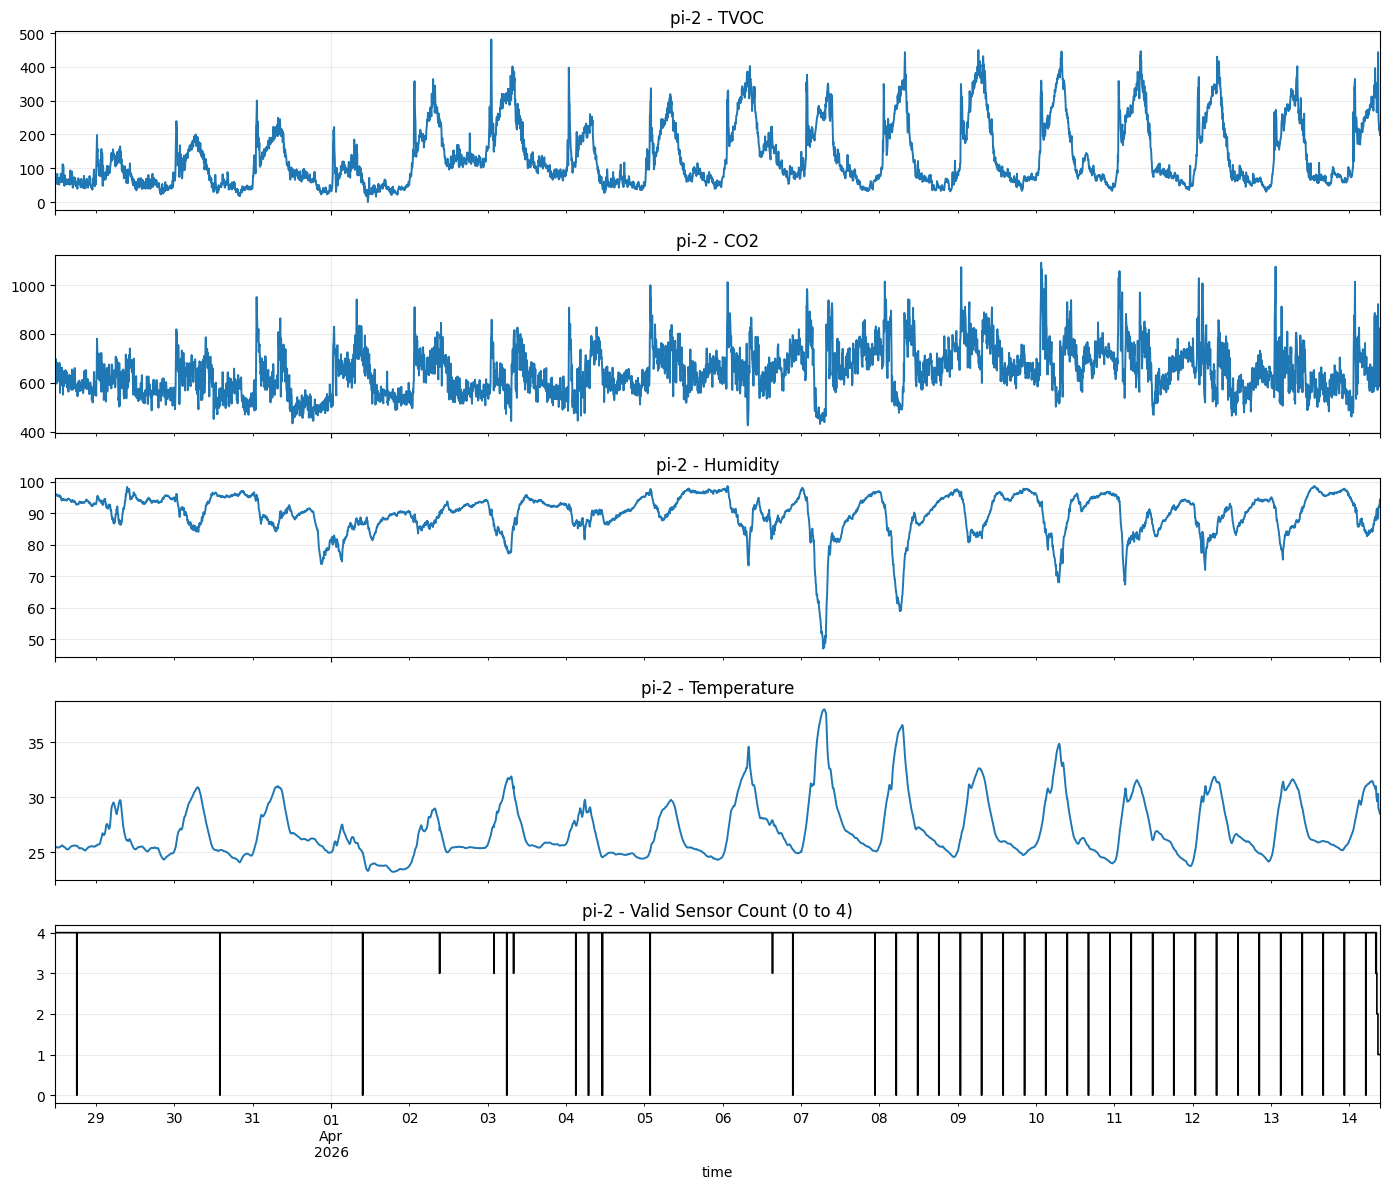

,input,output,rows_in,rows_5min,rows_with_le_2_sensors_working,dupe_timestamps_removed,delta_glitches_marked_total,rows_dropped_long_gaps,missing_after_fill_total
0,pi-1-data.csv,pi-1-data-clean-5min.csv,4861,4873,24,0,236,0,0
1,pi-2-data.csv,pi-2-data-clean-5min.csv,4838,4874,48,0,110,0,0


In [10]:
import matplotlib.pyplot as plt


def plot_cleaned_dataset(df: pd.DataFrame, title_prefix: str) -> None:
    plot_df = df.copy()
    plot_df["time"] = pd.to_datetime(plot_df["time"], utc=True)
    plot_df = plot_df.set_index("time")

    fig, axes = plt.subplots(5, 1, figsize=(14, 12), sharex=True)

    for ax, col, label in [
        (axes[0], "tvoc", "TVOC"),
        (axes[1], "co2", "CO2"),
        (axes[2], "humidity", "Humidity"),
        (axes[3], "temp", "Temperature"),
    ]:
        if col in plot_df.columns:
            plot_df[col].plot(ax=ax, linewidth=1.4)
        ax.set_title(f"{title_prefix} - {label}")
        ax.grid(alpha=0.25)

    max_valid = (
        int(plot_df["valid_sensor_count"].max())
        if "valid_sensor_count" in plot_df.columns
        else 0
    )
    if "valid_sensor_count" in plot_df.columns:
        plot_df["valid_sensor_count"].plot(
            ax=axes[4], linewidth=1.2, color="black", drawstyle="steps-mid"
        )
    axes[4].set_title(f"{title_prefix} - Valid Sensor Count (0 to {max_valid})")
    axes[4].grid(alpha=0.25)

    plt.tight_layout()
    plt.show()


for input_name, cleaned_df in cleaned_frames.items():
    prefix = input_name.replace("-data.csv", "").replace(".csv", "")
    plot_cleaned_dataset(cleaned_df, title_prefix=prefix)

clean_report_df

## Simulator


In [11]:
from pathlib import Path
from dataclasses import dataclass

import numpy as np
import pandas as pd


# Categorical spray dose (mg/L) to TVOC decay contribution and RH gain.
SPRAY_TVOC_DECAY: dict[int, float] = {
    0: 0.00,
    500: 0.06,
    1000: 0.12,
    1500: 0.22,
}

SPRAY_RH_GAIN: dict[int, float] = {
    0: 0.0,
    500: 0.45,
    1000: 0.9,
    1500: 1.4,
}


@dataclass
class Pi1SimulatorConfig:
    # Natural TVOC decay per 5-min step.
    natural_decay: float = 0.02
    # Decay used to recover emission from real data.
    baseline_decay: float = 0.02

    # RH dynamics.
    target_rh: float = 90.0
    rh_drift_rate: float = 0.01
    rh_min: float = 40.0
    rh_max: float = 100.0
    rh_alpha: float = (
        0.4  # inertial-like blending of real RH vs current RH for next step
    )

    # Noise scales.
    tvoc_noise_sigma: float = 2.0
    rh_noise_sigma: float = 0.1
    co2_noise_sigma: float = 15.0
    temp_noise_sigma: float = 0.2


class Pi1SpraySimulator:
    """Minimal simulator for RL prototyping on pi-1 5-minute data."""

    def __init__(
        self,
        pi1_df: pd.DataFrame,
        config: Pi1SimulatorConfig | None = None,
        seed: int = 7,
    ) -> None:
        self.cfg = config or Pi1SimulatorConfig()
        self.rng = np.random.default_rng(seed)

        required_cols = ["tvoc", "co2", "temp", "humidity"]
        missing = [c for c in required_cols if c not in pi1_df.columns]
        if missing:
            raise ValueError(f"Missing required columns: {missing}")

        base = pi1_df.copy()
        for col in required_cols:
            base[col] = pd.to_numeric(base[col], errors="coerce")
        base = base.dropna(subset=required_cols).reset_index(drop=True)

        if len(base) < 2:
            raise ValueError("Need at least 2 valid rows to compute emissions.")

        self.real_tvoc = base["tvoc"].to_numpy(dtype=float)
        self.real_co2 = base["co2"].to_numpy(dtype=float)
        self.real_temp = base["temp"].to_numpy(dtype=float)
        self.real_rh = base["humidity"].to_numpy(dtype=float)
        self.T = len(base)

        # emission(t) = real_tvoc(t+1) - real_tvoc(t) + baseline_decay * real_tvoc(t)
        self.emission = np.empty(self.T, dtype=float)
        self.emission[:-1] = (
            self.real_tvoc[1:]
            - self.real_tvoc[:-1]
            + self.cfg.baseline_decay * self.real_tvoc[:-1]
        )
        self.emission[-1] = self.emission[-2]

    @staticmethod
    def action_space() -> list[int]:
        return sorted(SPRAY_TVOC_DECAY.keys())

    def reset(self, t0: int = 0) -> np.ndarray:
        t0 = int(np.clip(t0, 0, self.T - 1))
        return np.array(
            [
                self.real_tvoc[t0],
                self.real_co2[t0],
                self.real_temp[t0],
                self.real_rh[t0],
            ],
            dtype=float,
        )

    def step(self, state: np.ndarray, action: int, t: int) -> np.ndarray:
        """(state, action, t) -> [tvoc_next, co2_next, temp_next, rh_next]."""
        if action not in SPRAY_TVOC_DECAY:
            raise ValueError(
                f"Unsupported action {action}. Use one of {self.action_space()}."
            )

        t = int(np.clip(t, 0, self.T - 2))
        tvoc, co2, temp, rh = [float(x) for x in state]

        # TVOC: current + emission - natural_decay*current - spray_decay*current + noise
        spray_decay = SPRAY_TVOC_DECAY[action]
        total_decay = np.clip(self.cfg.natural_decay + spray_decay, 0.0, 0.95)
        tvoc_next = (
            tvoc * (1.0 - total_decay)
            + self.emission[t]
            + self.rng.normal(0.0, self.cfg.tvoc_noise_sigma)
        )
        tvoc_next = max(0.0, tvoc_next)

        # CO2 / Temp: mostly exogenous replay + small noise.
        co2_next = self.real_co2[t + 1] + self.rng.normal(0.0, self.cfg.co2_noise_sigma)
        temp_next = self.real_temp[t + 1] + self.rng.normal(
            0.0, self.cfg.temp_noise_sigma
        )

        # RH: drift-to-target + spray gain + noise, then clamp.
        rh_base = self.real_rh[t + 1]

        # rh_next = (
        #     rh_base
        #     + SPRAY_RH_GAIN[action]
        #     + self.rng.normal(0.0, self.cfg.rh_noise_sigma)
        # )

        # rh_next = (
        #     rh
        #     + self.cfg.rh_drift_rate * (self.cfg.target_rh - rh)
        #     + SPRAY_RH_GAIN[action]
        #     + self.rng.normal(0.0, self.cfg.rh_noise_sigma)
        # )

        rh_next = (
            rh
            + self.cfg.rh_alpha * (rh_base - rh)
            + SPRAY_RH_GAIN[action]
            + self.rng.normal(0.0, self.cfg.rh_noise_sigma)
        )

        rh_next = float(np.clip(rh_next, self.cfg.rh_min, self.cfg.rh_max))

        return np.array([tvoc_next, co2_next, temp_next, rh_next], dtype=float)

    def rollout(self, actions: list[int], t0: int = 0) -> pd.DataFrame:
        """Run one trajectory and return a DataFrame for quick inspection."""
        t = int(np.clip(t0, 0, self.T - 2))
        state = self.reset(t)

        rows: list[dict[str, float | int]] = [
            {
                "t": t,
                "action": -1,
                "tvoc": state[0],
                "co2": state[1],
                "temp": state[2],
                "rh": state[3],
            }
        ]

        for a in actions:
            next_state = self.step(state, int(a), t)
            t += 1
            rows.append(
                {
                    "t": t,
                    "action": int(a),
                    "tvoc": next_state[0],
                    "co2": next_state[1],
                    "temp": next_state[2],
                    "rh": next_state[3],
                }
            )
            state = next_state

            if t >= self.T - 2:
                break

        return pd.DataFrame(rows)

    def compute_reward(
        self,
        tvoc_prev: float,
        tvoc_next: float,
        rh_next: float,
        action: int,
        tvoc_scale: float = 0.1,
        rh_scale: float = 0.5,
        action_scale: float = 0.001,
    ) -> float:
        """
        Reward for deodorization + RH constraint penalty.

        tvoc_scale: penalty per unit of TVOC
        rh_scale: penalty for RH deviation from target
        action_scale: penalty per unit of action (spray intensity)
        """
        tvoc_reduction = tvoc_prev - tvoc_next
        r_deodor = tvoc_scale * tvoc_reduction

        rh_target = self.cfg.target_rh
        rh_penalty = rh_scale * ((rh_next - rh_target) ** 2)

        action_penalty = action_scale * float(action)

        return float(r_deodor - rh_penalty - action_penalty)

Simulator initialized: T=4873 steps, action_space=[0, 500, 1000, 1500]


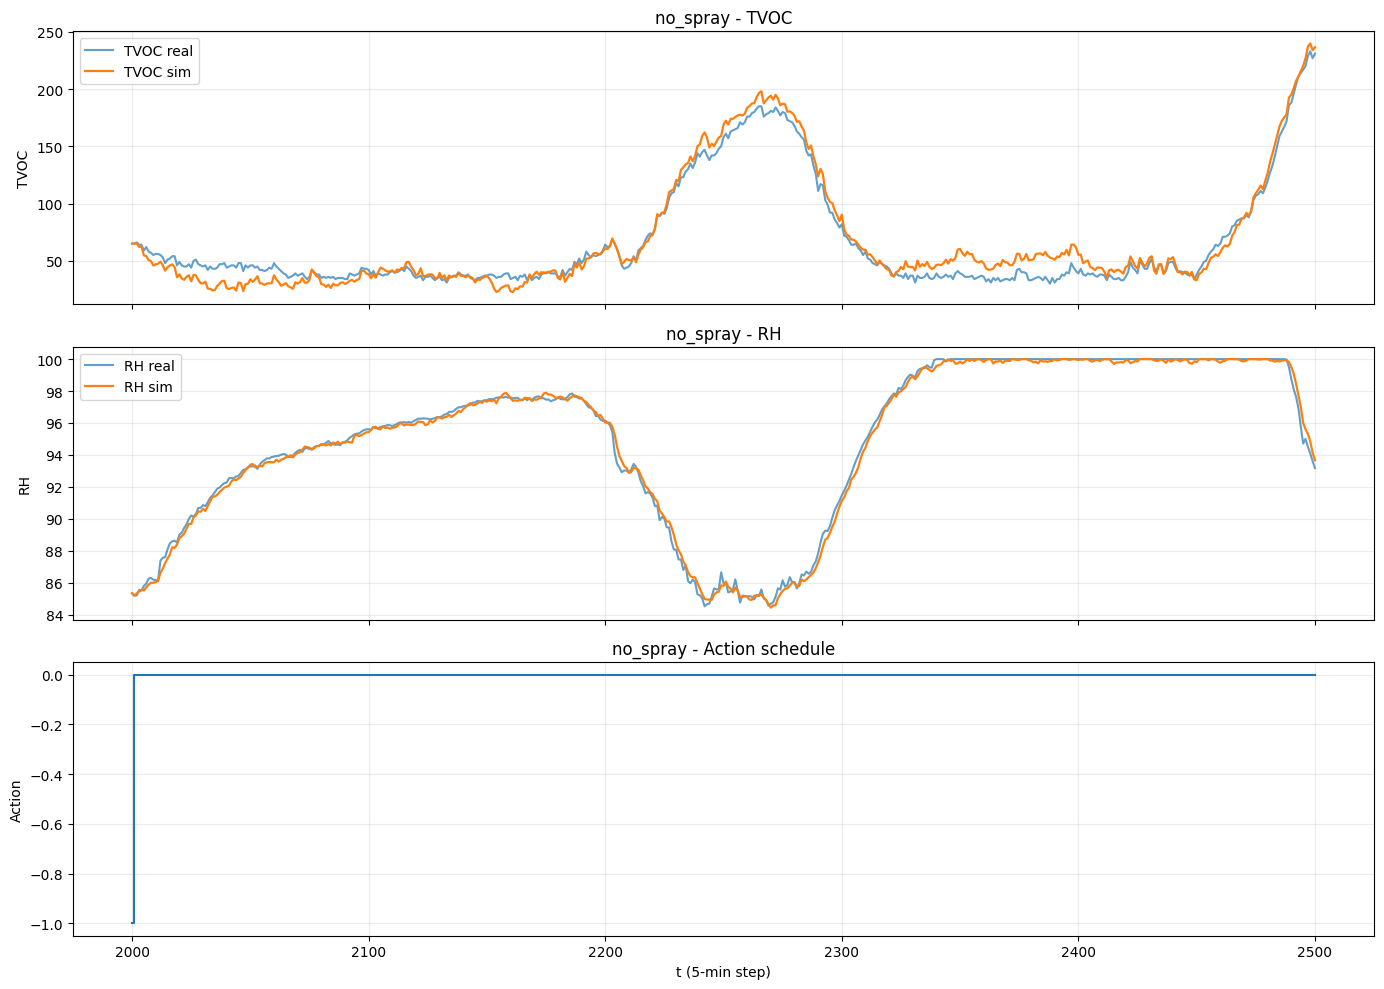

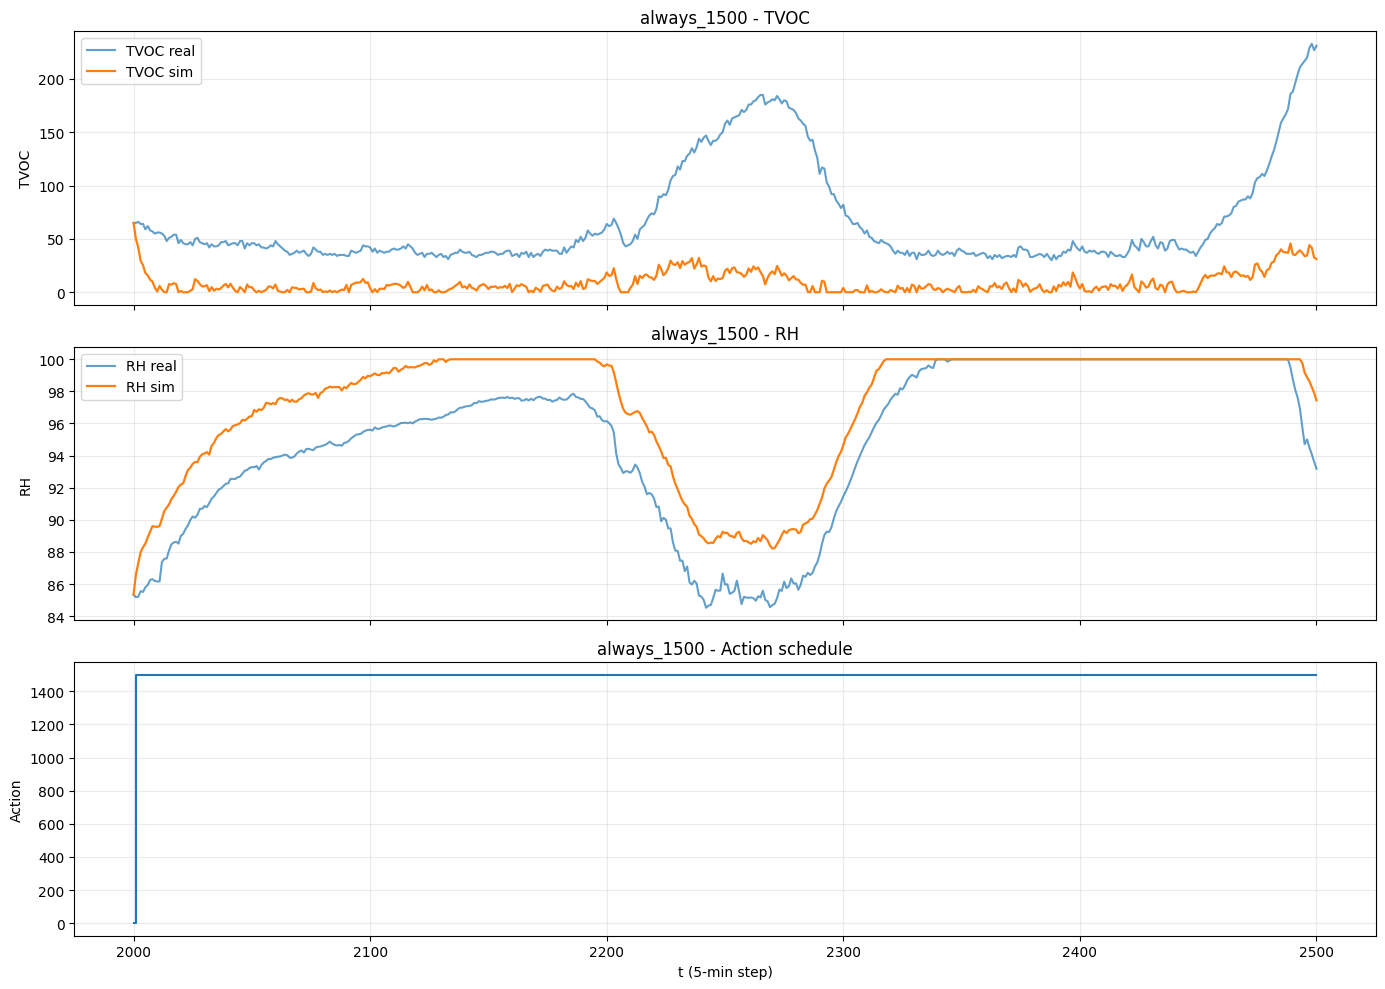

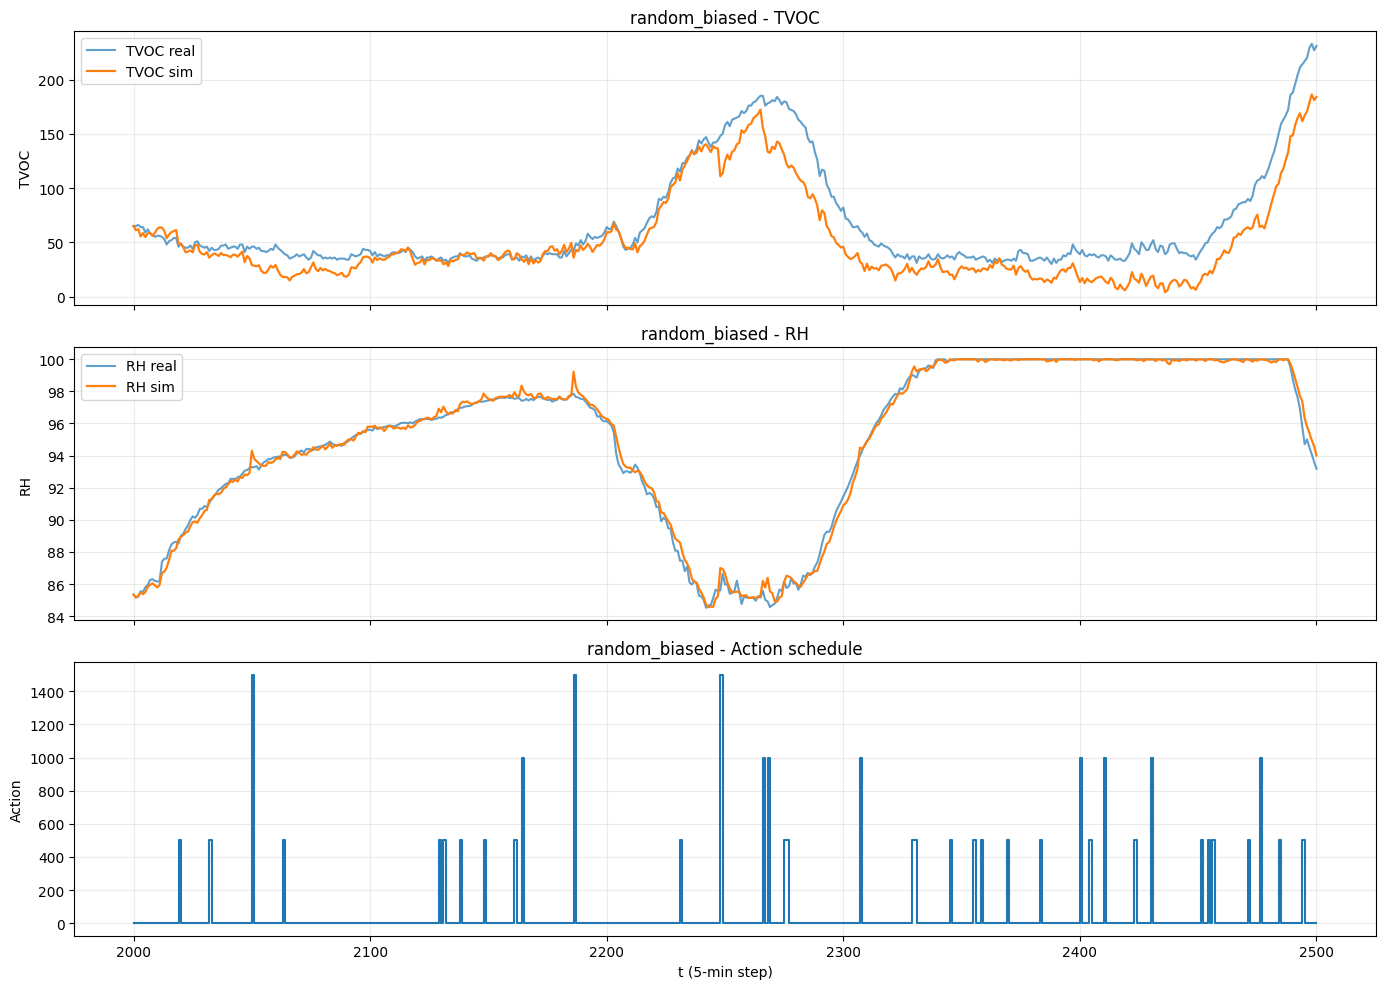

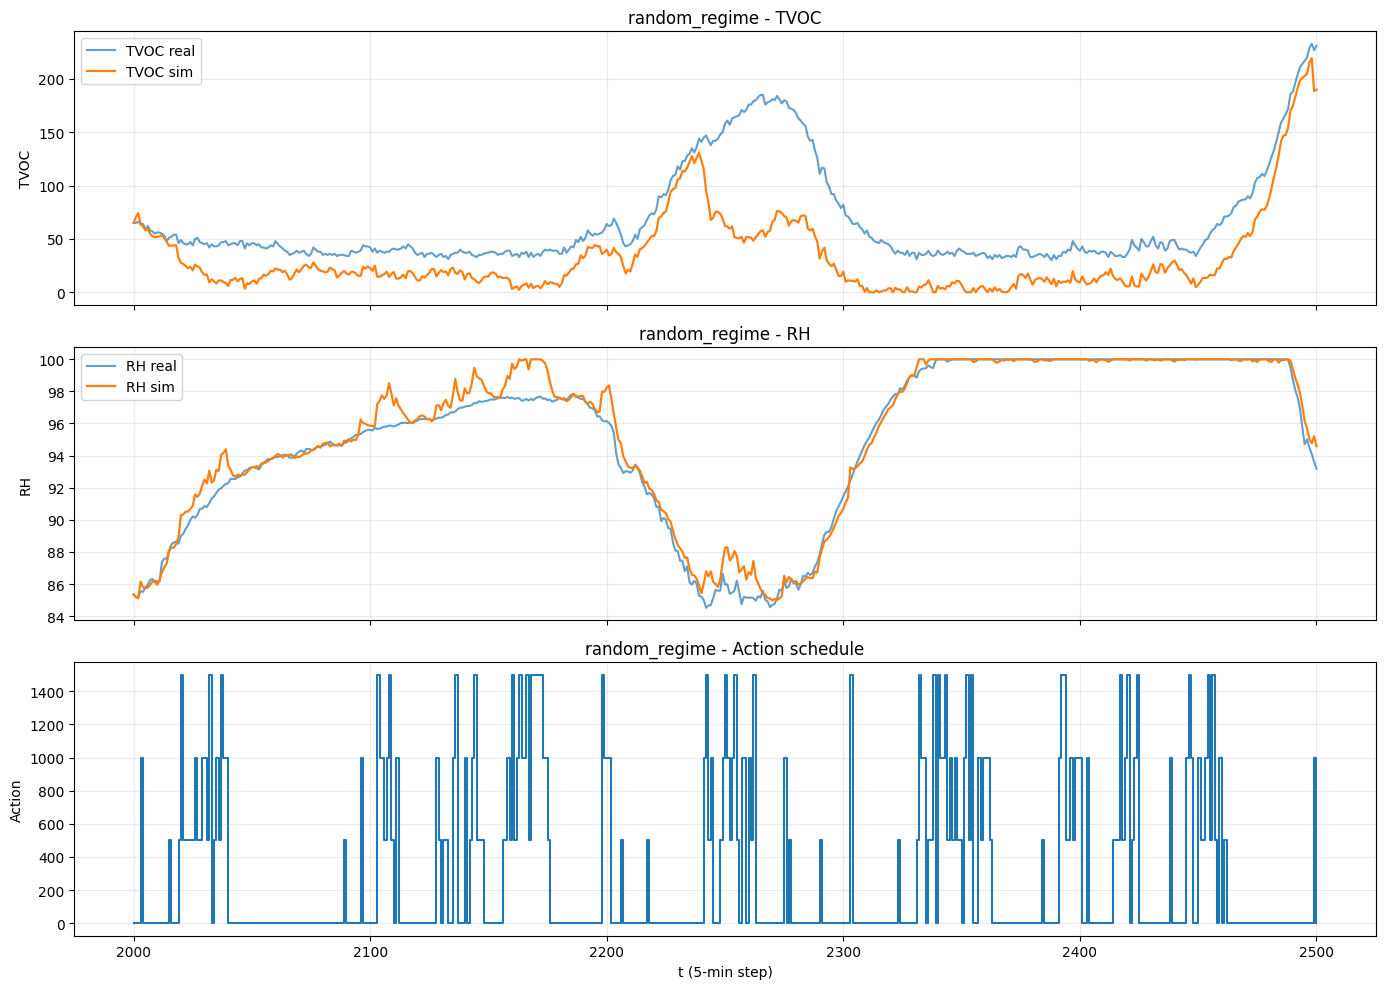

,case,steps,tvoc_start,tvoc_end,tvoc_change,tvoc_mae_vs_real,rh_start,rh_end,rh_change,tvoc_min,tvoc_max
0,no_spray,500,65.0,236.535428,171.535428,7.362255,85.34,93.672712,8.332712,22.674995,239.855061
1,always_1500,500,65.0,31.196440,-33.803560,57.497993,85.34,97.438625,12.098625,0.000000,65.000000
2,random_biased,500,65.0,183.841957,118.841957,16.497857,85.34,94.003545,8.663545,3.970634,186.286911
3,random_regime,500,65.0,190.018806,125.018806,33.587706,85.34,94.583226,9.243226,0.000000,219.462301


In [12]:
import matplotlib.pyplot as plt

# Build simulator from pi-1 only.
base_dir = Path.cwd()
if "cleaned_frames" in globals() and "pi-1-data.csv" in cleaned_frames:
    pi1_df = cleaned_frames["pi-1-data.csv"].copy()
else:
    pi1_df = pd.read_csv(base_dir / "pi-1-data-clean-5min.csv")

sim = Pi1SpraySimulator(pi1_df)
print(f"Simulator initialized: T={sim.T} steps, action_space={sim.action_space()}")


def _safe_horizon(simulator: Pi1SpraySimulator, requested_steps: int) -> int:
    """Clamp rollout length to available replay horizon."""
    return max(2, min(int(requested_steps), simulator.T - 2))


def make_action_plan(
    case: str,
    steps: int,
    rng: np.random.Generator | None = None,
) -> list[int]:
    """Build categorical action sequence for scenario testing."""
    case_key = case.strip().lower()
    local_rng = rng if rng is not None else np.random.default_rng(17)

    if case_key in {"no_spray", "none", "case1"}:
        return [0] * steps

    if case_key in {"always_1500", "max", "case2"}:
        return [1500] * steps

    if case_key in {"random_biased", "random", "rare_spray", "case3"}:
        # No spray is dominant; higher doses are progressively rarer.
        actions = np.array([0, 500, 1000, 1500], dtype=int)
        probs = np.array([0.90, 0.06, 0.03, 0.01], dtype=float)
        sampled = local_rng.choice(actions, size=steps, replace=True, p=probs)
        return sampled.tolist()

    if case_key in {"random_regime", "regime_switch", "bursty", "case4"}:
        # Regime-switching policy: long sparse periods and occasional bursty periods.
        actions = np.array([0, 500, 1000, 1500], dtype=int)
        low_probs = np.array([0.96, 0.03, 0.009, 0.001], dtype=float)
        high_probs = np.array([0.20, 0.30, 0.30, 0.20], dtype=float)

        # Persistence creates contiguous periods in each regime.
        p_stay_low = 0.97
        p_stay_high = 0.93
        in_high_regime = bool(local_rng.random() < 0.15)

        sampled_actions: list[int] = []
        for _ in range(steps):
            if in_high_regime:
                sampled_actions.append(int(local_rng.choice(actions, p=high_probs)))
                if local_rng.random() > p_stay_high:
                    in_high_regime = False
            else:
                sampled_actions.append(int(local_rng.choice(actions, p=low_probs)))
                if local_rng.random() > p_stay_low:
                    in_high_regime = True

        return sampled_actions

    raise ValueError(
        "Unknown case. Use one of: no_spray, always_1500, random_biased, random_regime."
    )


def run_case(
    simulator: Pi1SpraySimulator,
    case: str,
    steps: int = 288,
    t0: int = 0,
) -> tuple[pd.DataFrame, pd.DataFrame]:
    """Run one test case and return (simulated, real_reference) DataFrames."""
    safe_steps = _safe_horizon(simulator, steps)
    t0 = int(np.clip(t0, 0, simulator.T - safe_steps - 1))

    actions = make_action_plan(case, safe_steps, rng=simulator.rng)
    sim_df = simulator.rollout(actions, t0=t0).copy()

    real_slice = pd.DataFrame(
        {
            "t": np.arange(t0, t0 + safe_steps + 1),
            "tvoc_real": simulator.real_tvoc[t0 : t0 + safe_steps + 1],
            "co2_real": simulator.real_co2[t0 : t0 + safe_steps + 1],
            "temp_real": simulator.real_temp[t0 : t0 + safe_steps + 1],
            "rh_real": simulator.real_rh[t0 : t0 + safe_steps + 1],
        }
    )

    return sim_df, real_slice


def summarize_case(
    sim_df: pd.DataFrame, real_df: pd.DataFrame, case: str
) -> pd.DataFrame:
    """Compact metrics to support quick tuning iterations."""
    tvoc_start = float(sim_df["tvoc"].iloc[0])
    tvoc_end = float(sim_df["tvoc"].iloc[-1])
    rh_start = float(sim_df["rh"].iloc[0])
    rh_end = float(sim_df["rh"].iloc[-1])

    merged = sim_df.merge(real_df[["t", "tvoc_real"]], on="t", how="left")
    tvoc_mae = float((merged["tvoc"] - merged["tvoc_real"]).abs().mean())

    return pd.DataFrame(
        [
            {
                "case": case,
                "steps": int(len(sim_df) - 1),
                "tvoc_start": tvoc_start,
                "tvoc_end": tvoc_end,
                "tvoc_change": tvoc_end - tvoc_start,
                "tvoc_mae_vs_real": tvoc_mae,
                "rh_start": rh_start,
                "rh_end": rh_end,
                "rh_change": rh_end - rh_start,
                "tvoc_min": float(sim_df["tvoc"].min()),
                "tvoc_max": float(sim_df["tvoc"].max()),
            }
        ]
    )


def plot_case(sim_df: pd.DataFrame, real_df: pd.DataFrame, case: str) -> None:
    """Visual check for trend reproduction, suppression, and stability."""
    fig, axes = plt.subplots(3, 1, figsize=(14, 10), sharex=True)

    axes[0].plot(real_df["t"], real_df["tvoc_real"], label="TVOC real", alpha=0.7)
    axes[0].plot(sim_df["t"], sim_df["tvoc"], label="TVOC sim", linewidth=1.6)
    axes[0].set_ylabel("TVOC")
    axes[0].set_title(f"{case} - TVOC")
    axes[0].legend()
    axes[0].grid(alpha=0.25)

    axes[1].plot(real_df["t"], real_df["rh_real"], label="RH real", alpha=0.7)
    axes[1].plot(sim_df["t"], sim_df["rh"], label="RH sim", linewidth=1.6)
    axes[1].set_ylabel("RH")
    axes[1].set_title(f"{case} - RH")
    axes[1].legend()
    axes[1].grid(alpha=0.25)

    axes[2].step(sim_df["t"], sim_df["action"], where="post", label="Action (mg/L)")
    axes[2].set_ylabel("Action")
    axes[2].set_xlabel("t (5-min step)")
    axes[2].set_title(f"{case} - Action schedule")
    axes[2].grid(alpha=0.25)

    plt.tight_layout()
    plt.show()


def run_three_case_suite(
    simulator: Pi1SpraySimulator,
    steps: int = 288,
    t0: int = 0,
    plot: bool = True,
) -> tuple[dict[str, pd.DataFrame], pd.DataFrame]:
    """Run case scenarios and return trajectories + summary metrics."""
    cases = ["no_spray", "always_1500", "random_biased", "random_regime"]

    trajectories: dict[str, pd.DataFrame] = {}
    summary_frames: list[pd.DataFrame] = []

    for case in cases:
        sim_df, real_df = run_case(simulator, case=case, steps=steps, t0=t0)
        trajectories[case] = sim_df
        summary_frames.append(summarize_case(sim_df, real_df, case))
        if plot:
            plot_case(sim_df, real_df, case)

    summary_df = pd.concat(summary_frames, ignore_index=True)
    return trajectories, summary_df


# Execute default long-horizon checks (~24h at 5-minute resolution).
case_trajectories, case_summary_df = run_three_case_suite(
    sim, steps=500, t0=2000, plot=True
)
case_summary_df

In [13]:
import gymnasium as gym
from gymnasium import spaces


class Pi1SprayEnv(gym.Env):
    """Gymnasium-compliant environment for deodorization spray control."""

    metadata = {"render_modes": []}

    def __init__(
        self,
        simulator: Pi1SpraySimulator,
        tvoc_scale: float = 0.1,
        rh_scale: float = 0.5,
        action_scale: float = 0.001,
        max_steps: int = 500,
    ) -> None:
        self.sim = simulator
        self.tvoc_scale = tvoc_scale
        self.rh_scale = rh_scale
        self.action_scale = action_scale
        self.max_steps = max_steps

        # Action space: categorical [0, 500, 1000, 1500]
        self.action_to_dose = {
            0: 0,
            1: 500,
            2: 1000,
            3: 1500,
        }
        self.action_space = spaces.Discrete(4)

        # Observation: [tvoc, co2, temp, rh]
        self.observation_space = spaces.Box(
            low=np.array([0.0, 0.0, 0.0, 40.0], dtype=np.float32),
            high=np.array([500.0, 2000.0, 40.0, 100.0], dtype=np.float32),
            dtype=np.float32,
        )

        self.state: np.ndarray = np.zeros(4, dtype=np.float32)
        self.t: int = 0
        self.t_start: int = 0
        self.steps_taken: int = 0

    def reset(
        self, seed: int | None = None, options: dict | None = None
    ) -> tuple[np.ndarray, dict]:
        super().reset(seed=seed)
        self.t_start = self.np_random.integers(0, max(1, self.sim.T - self.max_steps))
        self.t = self.t_start
        self.state = self.sim.reset(t0=self.t_start).astype(np.float32)
        self.steps_taken = 0
        return self.state, {}

    def step(self, action: int) -> tuple[np.ndarray, float, bool, bool, dict]:
        """Execute one step and return (obs, reward, terminated, truncated, info)."""
        dose = self.action_to_dose[int(action)]
        state_prev = self.state.copy()
        next_state = self.sim.step(state_prev, dose, self.t).astype(np.float32)

        reward = self.sim.compute_reward(
            tvoc_prev=float(state_prev[0]),
            tvoc_next=float(next_state[0]),
            rh_next=float(next_state[3]),
            action=dose,
            tvoc_scale=self.tvoc_scale,
            rh_scale=self.rh_scale,
            action_scale=self.action_scale,
        )

        self.state = next_state
        self.t += 1
        self.steps_taken += 1

        terminated = self.t >= self.sim.T - 2
        truncated = self.steps_taken >= self.max_steps

        info = {
            "tvoc": float(self.state[0]),
            "rh": float(self.state[3]),
            "dose": dose,
        }

        return self.state, reward, terminated, truncated, info


# Instantiate environment
env = Pi1SprayEnv(
    sim, tvoc_scale=0.15, rh_scale=0.4, action_scale=0.0005, max_steps=500
)
print(
    f"Environment created: action_space={env.action_space}, obs_space={env.observation_space}"
)
print(f"Action mapping: {env.action_to_dose}")

Environment created: action_space=Discrete(4), obs_space=Box([ 0.  0.  0. 40.], [ 500. 2000.   40.  100.], (4,), float32)
Action mapping: {0: 0, 1: 500, 2: 1000, 3: 1500}


In [18]:
import os
import time

# Force CPU to avoid ROCm kernel crashes on unsupported gfx targets.
os.environ["CUDA_VISIBLE_DEVICES"] = ""

from stable_baselines3 import PPO
from stable_baselines3.common.env_util import make_vec_env

if "sim" not in globals():
    raise RuntimeError(
        "Simulator `sim` is not defined. Re-run cells 2 through 7 in order after a kernel restart."
    )

# Vectorized env for faster sampling in notebook-safe mode (DummyVecEnv).
N_ENVS = 4
N_STEPS = 128  # total rollout per update = N_ENVS * N_STEPS = 512

vec_env = make_vec_env(
    lambda: Pi1SprayEnv(
        sim,
        tvoc_scale=0.15,
        rh_scale=0.4,
        action_scale=0.0005,
        max_steps=500,
    ),
    n_envs=N_ENVS,
)

# Train PPO baseline.
print(f"Initializing PPO agent on CPU with VecEnv (n_envs={N_ENVS})...")
model = PPO(
    "MlpPolicy",
    vec_env,
    learning_rate=3e-4,
    n_steps=N_STEPS,
    batch_size=64,
    n_epochs=10,
    gamma=0.99,
    gae_lambda=0.95,
    clip_range=0.2,
    device="cpu",
    verbose=1,
)

print("\nTraining for 50k steps...")
start_train = time.time()
model.learn(total_timesteps=50000, log_interval=10)
elapsed = time.time() - start_train
print(f"Training completed in {elapsed:.1f}s.")

# Save model
model.save("/tmp/ppo_spray_baseline")
print("Model saved to /tmp/ppo_spray_baseline")

# Quick eval on a single non-vectorized env for readable episode metrics.
eval_env = Pi1SprayEnv(
    sim,
    tvoc_scale=0.15,
    rh_scale=0.4,
    action_scale=0.0005,
    max_steps=500,
)

print("\n=== Evaluation Rollout ===")
obs, _ = eval_env.reset(seed=42)
episode_reward = 0.0
episode_steps = 0
episode_tvoc_init = float(obs[0])
episode_rh_init = float(obs[3])

for _ in range(500):
    action, _ = model.predict(obs, deterministic=True)
    obs, reward, terminated, truncated, info = eval_env.step(int(action))
    episode_reward += reward
    episode_steps += 1
    if terminated or truncated:
        break

print(f"Episode length: {episode_steps} steps")
print(f"Episode cumulative reward: {episode_reward:.2f}")
print(f"Final TVOC: {info['tvoc']:.1f} (started at {episode_tvoc_init:.1f})")
print(f"Final RH: {info['rh']:.1f}% (started at {episode_rh_init:.1f}%)")

Initializing PPO agent on CPU with VecEnv (n_envs=4)...
Using cpu device

Training for 50k steps...
-----------------------------------------
| rollout/                |             |
|    ep_len_mean          | 500         |
|    ep_rew_mean          | -1.4e+04    |
| time/                   |             |
|    fps                  | 3971        |
|    iterations           | 10          |
|    time_elapsed         | 1           |
|    total_timesteps      | 5120        |
| train/                  |             |
|    approx_kl            | 0.011663485 |
|    clip_fraction        | 0.0252      |
|    clip_range           | 0.2         |
|    entropy_loss         | -1.29       |
|    explained_variance   | -1.23e-05   |
|    learning_rate        | 0.0003      |
|    loss                 | 8.47e+04    |
|    n_updates            | 90          |
|    policy_gradient_loss | -0.00492    |
|    value_loss           | 1.3e+05     |
-----------------------------------------
------------------

In [19]:
from collections import Counter


def evaluate_trained_model(
    trained_model: PPO,
    simulator: Pi1SpraySimulator,
    n_episodes: int = 20,
    max_steps: int = 500,
    seed: int = 123,
) -> pd.DataFrame:
    """Run deterministic evaluation and return aggregate metrics."""
    rewards: list[float] = []
    tvoc_delta: list[float] = []
    rh_violation_rate: list[float] = []
    action_counter: Counter[int] = Counter()

    for ep in range(n_episodes):
        eval_env = Pi1SprayEnv(
            simulator,
            tvoc_scale=0.15,
            rh_scale=0.4,
            action_scale=0.0005,
            max_steps=max_steps,
        )
        obs, _ = eval_env.reset(seed=seed + ep)

        ep_reward = 0.0
        ep_steps = 0
        ep_rh_violations = 0
        tvoc_start = float(obs[0])

        while True:
            action, _ = trained_model.predict(obs, deterministic=True)
            action_int = int(action)
            obs, reward, terminated, truncated, info = eval_env.step(action_int)

            ep_reward += float(reward)
            ep_steps += 1
            action_counter[int(info["dose"])] += 1

            if float(info["rh"]) > 95.0:
                ep_rh_violations += 1

            if terminated or truncated:
                break

        rewards.append(ep_reward)
        tvoc_delta.append(float(info["tvoc"]) - tvoc_start)
        rh_violation_rate.append(ep_rh_violations / max(1, ep_steps))

    total_actions = sum(action_counter.values())
    action_ratio = {
        f"dose_{dose}_ratio": action_counter.get(dose, 0) / max(1, total_actions)
        for dose in [0, 500, 1000, 1500]
    }

    out = {
        "episodes": n_episodes,
        "reward_mean": float(np.mean(rewards)),
        "reward_std": float(np.std(rewards)),
        "tvoc_delta_mean": float(np.mean(tvoc_delta)),
        "tvoc_delta_std": float(np.std(tvoc_delta)),
        "rh_violation_rate_mean": float(np.mean(rh_violation_rate)),
        **action_ratio,
    }
    return pd.DataFrame([out])


def train_and_evaluate_budget(
    simulator: Pi1SpraySimulator,
    total_timesteps: int,
    n_envs: int = 4,
    n_steps: int = 128,
    eval_episodes: int = 20,
    seed: int = 42,
) -> pd.DataFrame:
    """Train a fresh model for a given budget, then evaluate it."""
    vec = make_vec_env(
        lambda: Pi1SprayEnv(
            simulator,
            tvoc_scale=0.15,
            rh_scale=0.4,
            action_scale=0.0005,
            max_steps=500,
        ),
        n_envs=n_envs,
        seed=seed,
    )

    candidate = PPO(
        "MlpPolicy",
        vec,
        learning_rate=3e-4,
        n_steps=n_steps,
        batch_size=64,
        n_epochs=10,
        gamma=0.99,
        gae_lambda=0.95,
        clip_range=0.2,
        device="cpu",
        verbose=0,
        seed=seed,
    )
    candidate.learn(total_timesteps=total_timesteps)

    metrics = evaluate_trained_model(
        candidate,
        simulator,
        n_episodes=eval_episodes,
        max_steps=500,
        seed=seed + 1000,
    )
    metrics["timesteps"] = int(total_timesteps)
    return metrics


# Example 1: Evaluate current model quality.
# current_eval_df = evaluate_trained_model(
#     model, sim, n_episodes=20, max_steps=500, seed=123
# )
# current_eval_df

# Example 2: Compare training budgets (uncomment to run).
budgets = [50_000, 100_000, 200_000]
compare_df = pd.concat(
    [
        train_and_evaluate_budget(sim, total_timesteps=b, eval_episodes=10)
        for b in budgets
    ],
    ignore_index=True,
)
compare_df.sort_values("timesteps")

,episodes,reward_mean,reward_std,tvoc_delta_mean,tvoc_delta_std,rh_violation_rate_mean,dose_0_ratio,dose_500_ratio,dose_1000_ratio,dose_1500_ratio,timesteps
0,10,-13425.182264,5355.907144,-62.822651,43.511053,0.3926,0.7120,0.0,0.2880,0.0,50000
1,10,-13142.435208,4779.912352,-67.855138,42.772411,0.4058,0.5680,0.0,0.4320,0.0,100000
2,10,-13177.013061,5452.536414,-32.646164,45.181339,0.3796,0.8908,0.0,0.1092,0.0,200000
